This jupyter tutorial demonstrates how to find, download, and plot key variables from Global Navigation Satellite System Radio Occultation (GNSS RO) Data Products that have been reformatted to a common CF compliant format.

In [46]:
# import the libraries used in this notebook
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import time
from netCDF4 import Dataset, date2num
import os
import requests
from cmr import CollectionQuery, GranuleQuery, ToolQuery, ServiceQuery, VariableQuery
import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
import earthaccess
import concurrent.futures
import itertools
import pdb

Although the earthaccess library works to find granules for the GNSS-RO Level 2a and level 2b products, the current version of earthaccess (as of March 2026) fails for GNSS-RO Level 1b products since they lack spatial metadata.  However,  the python-cmr GranuleQuery() works.  This example will use a wrapper for GranuleQuery() that returns  "data", "opendap", and "S3" urls so it will be suitable for either downloading the data from a remote site or working with the data in Amamazon West cloud.  This search can also be acheived using the GranuleQuery() without the wrapper but for a large query it would return a lot of information that is not necessary.

In [47]:
def get_CMRgranurls(ShortName,VersionID,start_time,end_time,lon=None,lat=None,rad_km=None):
    """
    This program returns a dictionary with lists of "data", "opendap", and "S3" urls.  If lon, lat, and radius are given,
    this function will search for all granules defined by that circle.  If lon and lat are 2 element lists it will search for all
    granules defined by that bounding box.  If lon, lat, and radius_km are not given this function will search for all granules
    between the input start_time and end_time.  This function uses python-cmr to get the urls but it does not require prior
    knowledge of how many urls will be returned.
INPUTS
    "ShortName" the data set shortname written as a string
    "VersionID" the version ID of the product writtend as a string
    "start_time"  start time in utc.  The following is appended to the date: "T00:00:00Z.
    "end_time"  start time in utc The following is appended to the date: "T00:00:00Z, thus the end date is not actualy included
    in the results.
    "lon", "lat", "rad_km" (optional) will search within a radius or bounding box near a given location. If a radius or
    bounding box is not given, this function will return all granules within the input timerange.  
    OUTPUTS
    "urls" A dictionary with urls for the data, opendap, and s3 urls.  It also returns the start_time and end_time as they were
    modified by the program
     
EXAMPLES
    1) If a radius or bounding box are not specified it will return all granules for the given ShortName and VersionID that have
    times that overlap with thie input time range.
    > urls = get_CMRgranurls(ShortName,VersionID,'2002.09.01','2002.09.02')    
    
    2) If a point and radius are given the program will return all of the granules for the given ShortName and VersionID that have
    times that overlap with the given time range and positions that overlap with the given circle.
    > urls = get_CMRgranurls(ShortName,VersionID,'2002.09.01','2016.01.01',lon=-90.0667,lat=29.95, rad_km=30.0)

    3) if a bounding box is specified the program will return all of the granules for the given ShortName and VersionID that have
    times that overlap with the given time range and positions that overlap with the given bounding box.

    HISTORY
    Created by Thomas Hearty,  March 14, 2016 
    """
    start_time = start_time.replace('.','-')
    end_time = end_time.replace('.','-')
    if len(start_time) == 10:
        start_time = start_time+"T00:00:00Z"
        end_time = end_time+"T00:00:00Z"

    # create a list of start and end times strings
    start_dt = datetime.datetime.fromtimestamp(time.mktime(time.strptime(start_time,"%Y-%m-%dT%H:%M:%SZ")))
    end_dt = datetime.datetime.fromtimestamp(time.mktime(time.strptime(end_time,"%Y-%m-%dT%H:%M:%SZ")))
    
    deltatime = end_dt - start_dt
    start_times = [start_time]
    end_times = []
    timeincrement = datetime.timedelta(7)
    while deltatime > timeincrement:
        old_start_dt = start_dt
        start_dt = old_start_dt+timeincrement
        end_times.append(start_dt.strftime("%Y-%m-%dT%H:%M:%SZ"))
        start_times.append(end_times[-1])
        deltatime = end_dt - start_dt
    end_times.append(end_time)
 
    s3_urls = []
    opendap_urls = []
    data_urls = []
    for start_time_seg,end_time_seg in zip(start_times,end_times):
        api = GranuleQuery()

        # there are three types of searches that I can do.  1) global, 2) bounding box, 3) point radius
        if rad_km is None and lon is None and lat is None: # this is a global search
            granules = api.short_name(ShortName).version(VersionID).temporal(start_time_seg,end_time_seg).get(1000000) 
        elif rad_km is None and len(lon) == 2 and len(lat) == 2:
            granules = api.short_name(ShortName).version(VersionID).temporal(start_time_seg,end_time_seg).bounding_box(lon[0],lat[0],lon[1],lat[1]).get(1000000)
        else: # for now I will assume it is a circle
            granules = api.short_name(ShortName).version(VersionID).temporal(start_time_seg,end_time_seg).circle(lon,lat,rad_km*1000.).get(1000000)
        
        for granule in granules:
            for link in granule.get('links',[]):
                if 'rel' in link and 'href' in link and 'inherited' not in link:
                    if 'http://esipfed.org/ns/fedsearch/1.1/s3#' in link['rel']: # It's an s3 url
                        s3_urls.append(link['href'])
                    if 'http://esipfed.org/ns/fedsearch/1.1/service#' in link['rel'] and 'opendap' in link['href']: # It's an opendap link
                        opendap_urls.append(link['href'])
                    if 'http://esipfed.org/ns/fedsearch/1.1/data#' in link['rel']: # It's a data url
                        data_urls.append(link['href'])
        
        # Get just the URLs (identified by 'via S3' in the link title)
        ###s3_urls_seg = [link['href'] for link in gran_links if 'http://esipfed.org/ns/fedsearch/1.1/s3#' in link['rel']]

        # Get just the URLs (identified by 'OPENDAP location for the granule' in the link title)
        ###opendap_urls_seg = [link['href'] for link in gran_links if 'OPENDAP location for the granule' in link['title']]

        # Finally, get just the URLs (identified by 'Download' in the link title)
        ###data_urls_seg = [link['href'] for link in gran_links if 'http://esipfed.org/ns/fedsearch/1.1/data#' in link['rel']]
            
    # we did this already, but lets do it again because the same file can appear in multiple segments.
    s3_urls = list(set(s3_urls)) # makes them unique and sorts them
    opendap_urls = list(set(opendap_urls)) # makes them unique and sorts them
    data_urls = list(set(data_urls)) # makes them unique and sorts them
    s3_urls.sort() # this will probably put them in chronological order but it must be verified.
    opendap_urls.sort() # this will probably put them in chronological order but it must be verified.
    data_urls.sort() # this will probably put them in chronological order but it must be verified.
    urls = {'s3':s3_urls,'opendap':opendap_urls,'data':data_urls}
    
    return urls,start_time,end_time

In [48]:
# These functions are used to download a list of URLS

def download_granule(url, datadir, max_retries=3, retry_delay=5):
    print("Opening " + url)

    localfile = os.path.join(datadir, os.path.basename(url))
    
    # Skip if file already downloaded
    if os.path.exists(localfile):
        #print(f"File already exists, skipping: {localfile}")
        return localfile # Assume the previously downloaded file is correct
    
    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(url, headers={'Accept-Encoding': 'identity'}, timeout=30)
            if response.ok:
                with open(localfile, 'wb') as file_handler:
                    file_handler.write(response.content)
                    # Ensure all data was written
                    if file_handler.tell() != len(response.content):
                        print("Size mismatch! Potential data loss:"+url)
                        return url # return the url so it can be downloaded again
                    else:
                        #Size matches exactly 
                        return localfile
            else:
                print(f"Request failed (attempt {attempt}): {response.status_code} - {response.text}")
        except Exception as e:
            print(f"Download error on attempt {attempt} for {localfile}: {e}")
        
        if attempt < max_retries:
            time.sleep(retry_delay)

    print(f"Failed to download after {max_retries} attempts: {localfile}")

def download_granules(urls, datadir):
    if isinstance(urls,str):
        urls = [urls] # If it's a string make it a list so we can itterate even if it's just one.
    local_filenames = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
        for result in executor.map(download_granule, urls, itertools.repeat(datadir)):
            local_filenames.append(result)
    return local_filenames

#l1b_local = download_granules(l1b_urls['data'],datadir)


The following parameters make the plot easier to read.

In [49]:
axeslinewidth = 1.5
plt.rcParams.update( {
  'font.family': "Nimbus Roman", 
  'font.size': 24, 
  'font.weight': "normal", 
  'text.usetex': False, 
  'xtick.major.width': axeslinewidth, 
  'xtick.minor.width': axeslinewidth, 
  'ytick.major.width': axeslinewidth, 
  'ytick.minor.width': axeslinewidth, 
  'axes.linewidth': axeslinewidth } )

The following lines prepare start and end dates (date1 and date2), the ShortName, and the Version that are used as input to "get_CMRgranurls" to find the l1b, l2a, and l2b granule urls for a given day.

In [50]:
# Start and End Dates
date1 = datetime.date(2007,3,26) #t0 in the original code
date2 = date1 + datetime.timedelta(days=1) #t1 in the original code

# ShortNames
l1b_shortname = 'gnssro_cosmic1_eumetsat_l1b'
l2a_shortname = 'gnssro_cosmic1_romsaf_l2a'
l2b_shortname = 'gnssro_cosmic1_romsaf_l2b'

#Version
VersionID = '2.0'

In [51]:
# Use get_CMRgranurls to get a list of l1b, l2a, and l2b files
l1b_urls,out_time_start,out_time_end =  get_CMRgranurls(l1b_shortname,VersionID,date1.isoformat(),date2.isoformat())
l2a_urls,out_time_start,out_time_end =  get_CMRgranurls(l2a_shortname,VersionID,date1.isoformat(),date2.isoformat())
l2b_urls,out_time_start,out_time_end =  get_CMRgranurls(l2b_shortname,VersionID,date1.isoformat(),date2.isoformat())

In [52]:
print("Number of granules for the {}, {}, and {} products \nfrom {} \nto {}".format(l1b_shortname,l2a_shortname,l2b_shortname,out_time_start,out_time_end))
print("Level 1B Files:{}".format(len(l1b_urls['data'])))
print("Level 2A Files:{}".format(len(l2a_urls['data'])))
print("Level 2b Files:{}".format(len(l2b_urls['data'])))

Number of granules for the gnssro_cosmic1_eumetsat_l1b, gnssro_cosmic1_romsaf_l2a, and gnssro_cosmic1_romsaf_l2b products 
from 2007-03-26T00:00:00Z 
to 2007-03-27T00:00:00Z
Level 1B Files:2140
Level 2A Files:2054
Level 2b Files:2054


In general the number of Level 2 products is less than the number of Level 1 products since selection effects may reduce the number of successful retrievals.  However, we have noticed that there can occationally be fewer Level 1 products for a given day if the lower level products were not saved.

We will now show how to download the files using the "data" urls.  However, if you are working in the amazon west-2 cloud, it would also be possible to read the "s3" url directly.

In [53]:
# Create a directory to which the original data files can be downloaded
datadir = './data/' # this is where I will download the files
if os.path.exists(datadir) is False:
    os.makedirs(datadir)

In [55]:
# this is how we use the "download_granules" function we created above to download the files.
# For now just download the firest granule of each type
l1b_local = download_granules(l1b_urls['data'][0],datadir)
l2a_local = download_granules(l2a_urls['data'][0],datadir)
l2b_local = download_granules(l2b_urls['data'][0],datadir)

Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_eumetsat_l1b.2.0/2007/03/26/gnssro_cosmic1_eumetsat_l1b_0100_cosmic1c1-G01-200703260021.nc4
Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_romsaf_l2a.2.0/2007/03/26/gnssro_cosmic1_romsaf_l2a_2304.0010_cosmic1c1-G01-200703260021.nc4
Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_romsaf_l2b.2.0/2007/03/26/gnssro_cosmic1_romsaf_l2b_2304.0010_cosmic1c1-G01-200703260021.nc4


In [37]:
# this is how we use the "download_files" function we created above to download the files.
l1b_local = download_files('l1b_dataurls.txt',datadir)
l2a_local = download_files('l2a_dataurls.txt',datadir)
l2b_local = download_files('l2b_dataurls.txt',datadir)

./data/gnssro_cosmic1_romsaf_l2a_2304.0010_cosmic1c1-G01-200703260021.nc4length is 154007
./data/gnssro_cosmic1_romsaf_l2b_2304.0010_cosmic1c1-G01-200703260021.nc4length is 28078


In [56]:
# It is possible to get the occultation ID from the filename as shown below:
l1b_occid = l1b_urls['data'][0].split('.nc4')[0].split('_')[-1]
l2a_occid = l2a_urls['data'][0].split('.nc4')[0].split('_')[-1]
l2b_occid = l2b_urls['data'][0].split('.nc4')[0].split('_')[-1]

# Since the different processing levels may have different numbers of granules, the indices of the arrays may not match up
# so it is always good to check the occultation ID.
print('These first 3 granules all have the following Occultation IDs:')
print(l1b_occid)
print(l2a_occid)
print(l2b_occid)

These first 3 granules all have the following Occultation IDs:
cosmic1c1-G01-200703260021
cosmic1c1-G01-200703260021
cosmic1c1-G01-200703260021


If the filename is ever changed the following function uses the file metadata to generate the occultation ID

In [57]:
def gen_occid(file):
    # A program to generate the occultation ID based on the file metadata.
    # This is usefull if the filename has ever changed and it is not possible to get the occultation ID from the filename
    #
    #Caveat: There might be small discrepancies in the occultation ID from different processing centers.
    d = Dataset( file, 'r' )
    occid_time = ''.join(d.RangeBeginningDate.split('-'))+''.join(d.RangeBeginningTime.split(':')[0:2]) # The date string in the occultation id is the RangeBeginningDate and RangeBeginningTime with just the numbers and no seconds (yyyymmddhhnn).  See the README document for more details.
    occid = "-".join([d.receiver,d.transmitter,occid_time])
    d.close()
    return occid

In [58]:
# This demonstrates how to print the occultation ID using gen_occid.
print('These first 3 granules all have the following Occultation IDs:')
print(gen_occid(l1b_local[0]))
print(gen_occid(l2a_local[0]))
print(gen_occid(l2b_local[0]))

These first 3 granules all have the following Occultation IDs:
cosmic1c1-G01-200703260021
cosmic1c1-G01-200703260021
cosmic1c1-G01-200703260021


Let's try to plot a L1B granule:

In [64]:
def freqname(freq):
    '''
This is a function to find the Name of the input frequncies (which we will call channels so they will not be confused with
processing levels).
Input: The GNSS-RO files have the a variable called "carrier_frequency" that provides the frequency in Hz
Output: a dictionary with the names within 10% of the input frequency.  The input frequency is converted to MHz
    '''
    freq_mhz = freq/1e6 # the input frequency is Hz, the output frequency is MHZ
    # It may be necessary to add other channels to this dictionary for different missions
    channels = {'L1 Channel' : 1575.42,
                 'L2 Channel': 1227.6,
                 'L5 Channel': 1176.45}

    # set the output to be a dictionary representing the names of the input frequency.
    matches = {channel:freq_mhz for channel,value in channels.items() if abs(freq_mhz-channels[channel])<channels[channel]*0.01} 
    return matches

In [65]:
def plot_l1b(l1b_file):
    occid = gen_occid(l1b_file)
    
    d = Dataset(l1b_file, 'r')

    # get the relevant variables
    excess_phase = d.variables['excess_phase'][:]
    snr = d.variables['snr'][:]
    time = d.variables['time'][:]
    carrier_frequency = d.variables['carrier_frequency'][:]
    # get the relevant global attributes
    ShortName = d.ShortName

    d.close()
    colors = ( "#FF0000", "#0000FF" )
    #xticks = np.arange( 0, 240.1, 60 )
    xticks = np.arange( 0, 100.1, 60 )
    fig = plt.figure( figsize=(15,12) )
    ax1 = fig.add_axes( [0.10,0.52,0.83,0.41] )
    ax2 = fig.add_axes( [0.10,0.08,0.83,0.41] )
    
    #fig, (ax1, ax2) = plt.subplots(2, 1, constrained_layout=True)
    fig.suptitle(ShortName+': '+occid, fontsize=30)
    ax1.set_xlim(0.,100.)
    ax1.set_xticks( xticks )
    ax1.xaxis.set_minor_locator( MultipleLocator(10) )
    ax1.set_ylim( excess_phase.min()/1000., excess_phase.max()/1000. ) # Divide by 1000 to convert m to km.
    #ax1.set_yticks( np.arange( 0.0, 10.01, 5.0 ) )
    ax1.yaxis.set_minor_locator( MultipleLocator(1) )
    ax1.set_xticklabels( [] )
    ax1.set_ylabel( "Excess phase [km]" ) 

    band0_matches = freqname(carrier_frequency[0])
    band1_matches = freqname(carrier_frequency[1])

    band0_1 = ax1.plot( time, excess_phase[0,:]/1000, color=colors[0], label =','.join(band0_matches.keys()), lw=3 )
    band1_1 = ax1.plot( time, excess_phase[1,:]/1000, color=colors[1], label =','.join(band1_matches.keys()), lw=2 )

    ax1.legend(handles=[band0_1[0], band1_1[0]])

    #ax2.set_xlim( 0, 240 )*** change back to other
    ax2.set_xlim( 0, 100 )
    ax2.set_xticks( xticks )
    ax2.xaxis.set_minor_locator( MultipleLocator(10) )
    ax2.set_ylim( 0.0, 2000.0 )
    ax2.set_yticks( np.arange( 0.0, 2000.01, 500.0 ) )
    ax2.yaxis.set_minor_locator( MultipleLocator(100) )
    ax2.set_xlabel( "Time since epoch [s]" )
    ax2.set_ylabel( "SNR" )
    
    #L1 = ax2.plot( time, snr[:,0], color=colors[0], label ="$^{L1} SNR$", lw=0.9 )
    #L2 = ax2.plot( time, snr[:,1], color=colors[1], label ="$^{L2} SNR$",lw=0.9 )
    band0_2 = ax2.plot( time, snr[0,:], color=colors[0], lw=3 )
    band1_2 = ax2.plot( time, snr[1,:], color=colors[1], lw=2 )
    #plt.savefig(l1b_file+'_image.png')
    #plt.close()
    

    

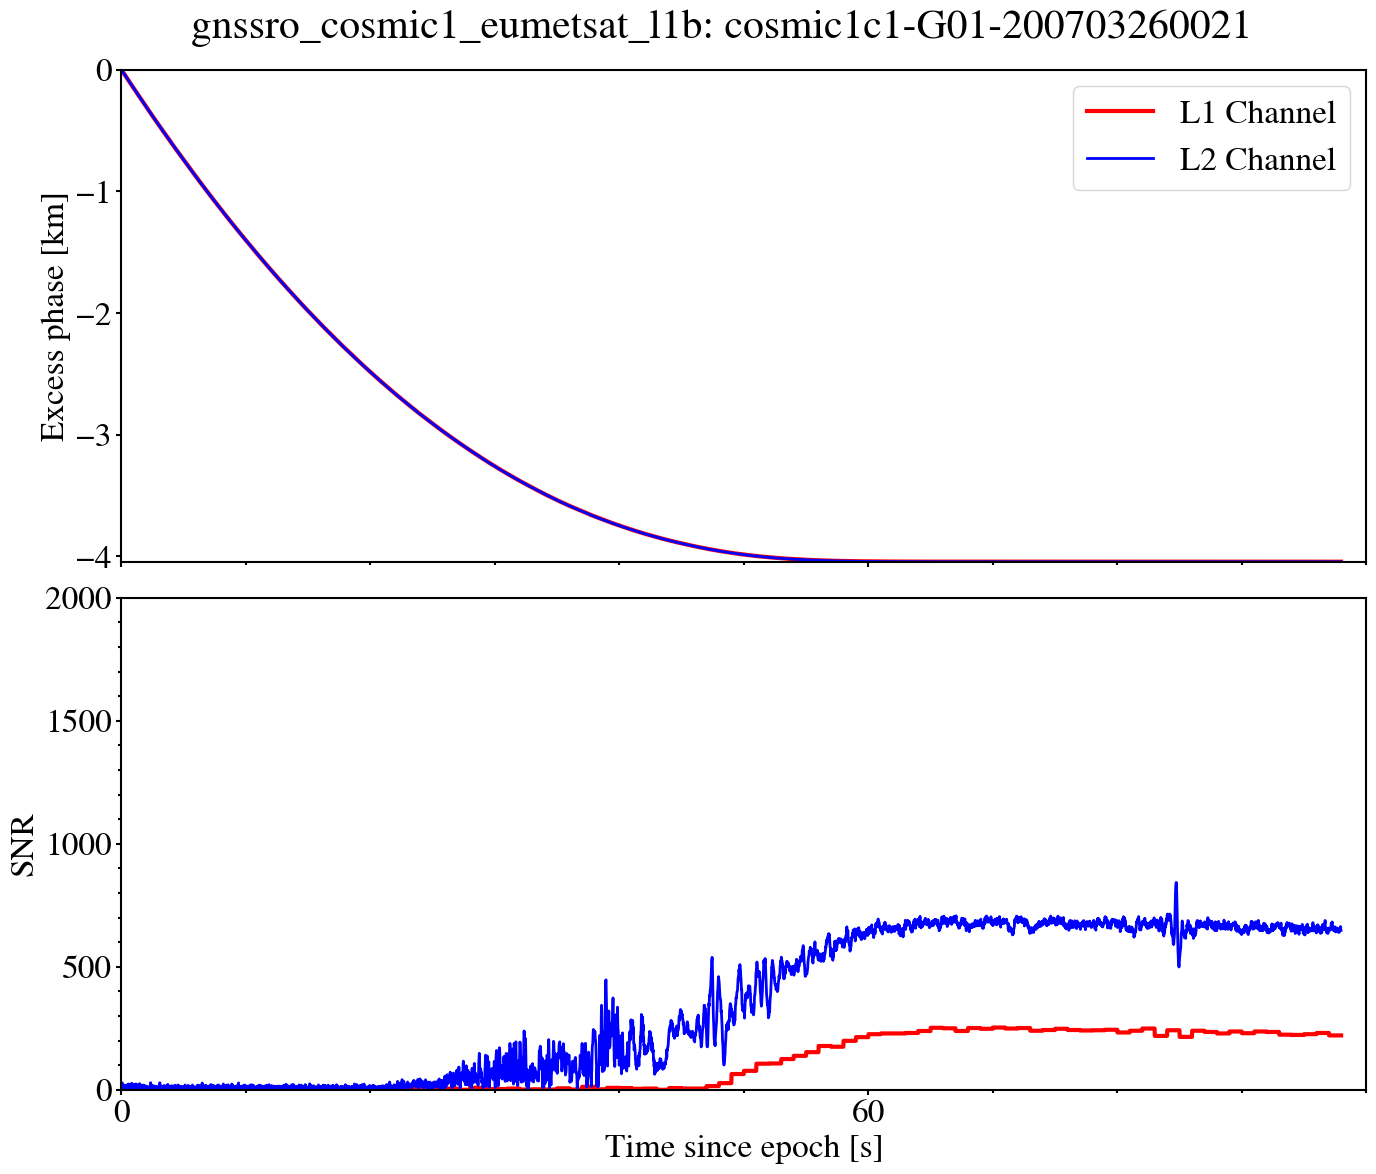

In [66]:
plot_l1b(l1b_local[0])

Now lets plot a Level 2A granule.

In [67]:
def plot_l2a(l2a_file):
    #occid = l2a_file.split('.nc4')[0].split('_')[-1]
    occid = gen_occid(l2a_file)
    d = Dataset(l2a_file, 'r' )

    #bending_angle = d.variables['bendingAngle'][:] 
    bending_angle = d['pre_Abel'].variables['raw_bending_angle'][:] #*change back for all other RO missions
    impact_parameter = d['pre_Abel'].variables['impact_parameter'][:]
    radius_of_curvature = d['pre_Abel'].variables['radius_of_curvature'][:]
    carrier_frequency = d['pre_Abel'].variables['carrier_frequency'][:]
    refractivity = d['post_Abel'].variables['refractivity'][:]
    altitude = d['post_Abel'].variables['altitude'][:]
    
    
    # get the relevant global attributes
    ShortName = d.ShortName
    d.close()
    colors = ( "#FF0000", "#0000FF" )
    
    fig = plt.figure( figsize=(15,12) )
    ax1 = fig.add_axes( [0.10,0.10,0.36,0.83] )
    ax2 = fig.add_axes( [0.56,0.10,0.36,0.83] )
    fig.suptitle(ShortName+': '+occid, fontsize=30)

    #ax1.set_xlim( -2, 30 )
    ax1.set_xlim( -2, 45 )
    #ax1.set_xticks( np.arange(0,30.1,10) )
    ax1.set_xticks( np.arange(0,45.1,10) )
    ax1.xaxis.set_minor_locator( MultipleLocator(2) )
    ax1.set_ylim( 0.0, 30.0 )
    ax1.set_yticks( np.arange( 0.0, 30.01, 10 ) )
    ax1.yaxis.set_minor_locator( MultipleLocator(2) )
    ax1.set_xlabel( "Raw Bending Angle [mrad]" )
    ax1.set_ylabel( "Impact height [km]" )

    band0_matches = freqname(carrier_frequency[0])
    band1_matches = freqname(carrier_frequency[1])
    
    band0 = ax1.plot( bending_angle[:,0]*1000, ( impact_parameter - radius_of_curvature )/1000, color=colors[0], label =','.join(band0_matches.keys()),lw=3 )
    band1 = ax1.plot( bending_angle[:,1]*1000, ( impact_parameter - radius_of_curvature )/1000, color=colors[1], label =','.join(band1_matches.keys()),lw=2 ) #*put back for all other GNSS RO (see original code)
    ax1.legend(handles=[band0[0], band1[0]]) #*put back for all other GNSS RO

    #ax2.set_xlim( 0, 300 )
    ax2.set_xlim( 0, 400 )
    #ax2.set_xticks( np.arange(0.0,300.1,100) )
    ax2.set_xticks( np.arange(0.0,400.1,100) )
    ax2.xaxis.set_minor_locator( MultipleLocator(20) )
    ax2.set_ylim( 0.0, 30.0 )
    ax2.set_yticks( np.arange( 0.0, 30.01, 10.0 ) )
    ax2.yaxis.set_minor_locator( MultipleLocator(2) )
    #ax2.set_xlabel( "Refractivity [$N$-units]" )
    ax2.set_xlabel( "Refractivity" )
    ax2.set_ylabel( "Altitude [km]" )
    
    ax2.plot( refractivity, altitude/1000, color="#000000", lw=2.25 )


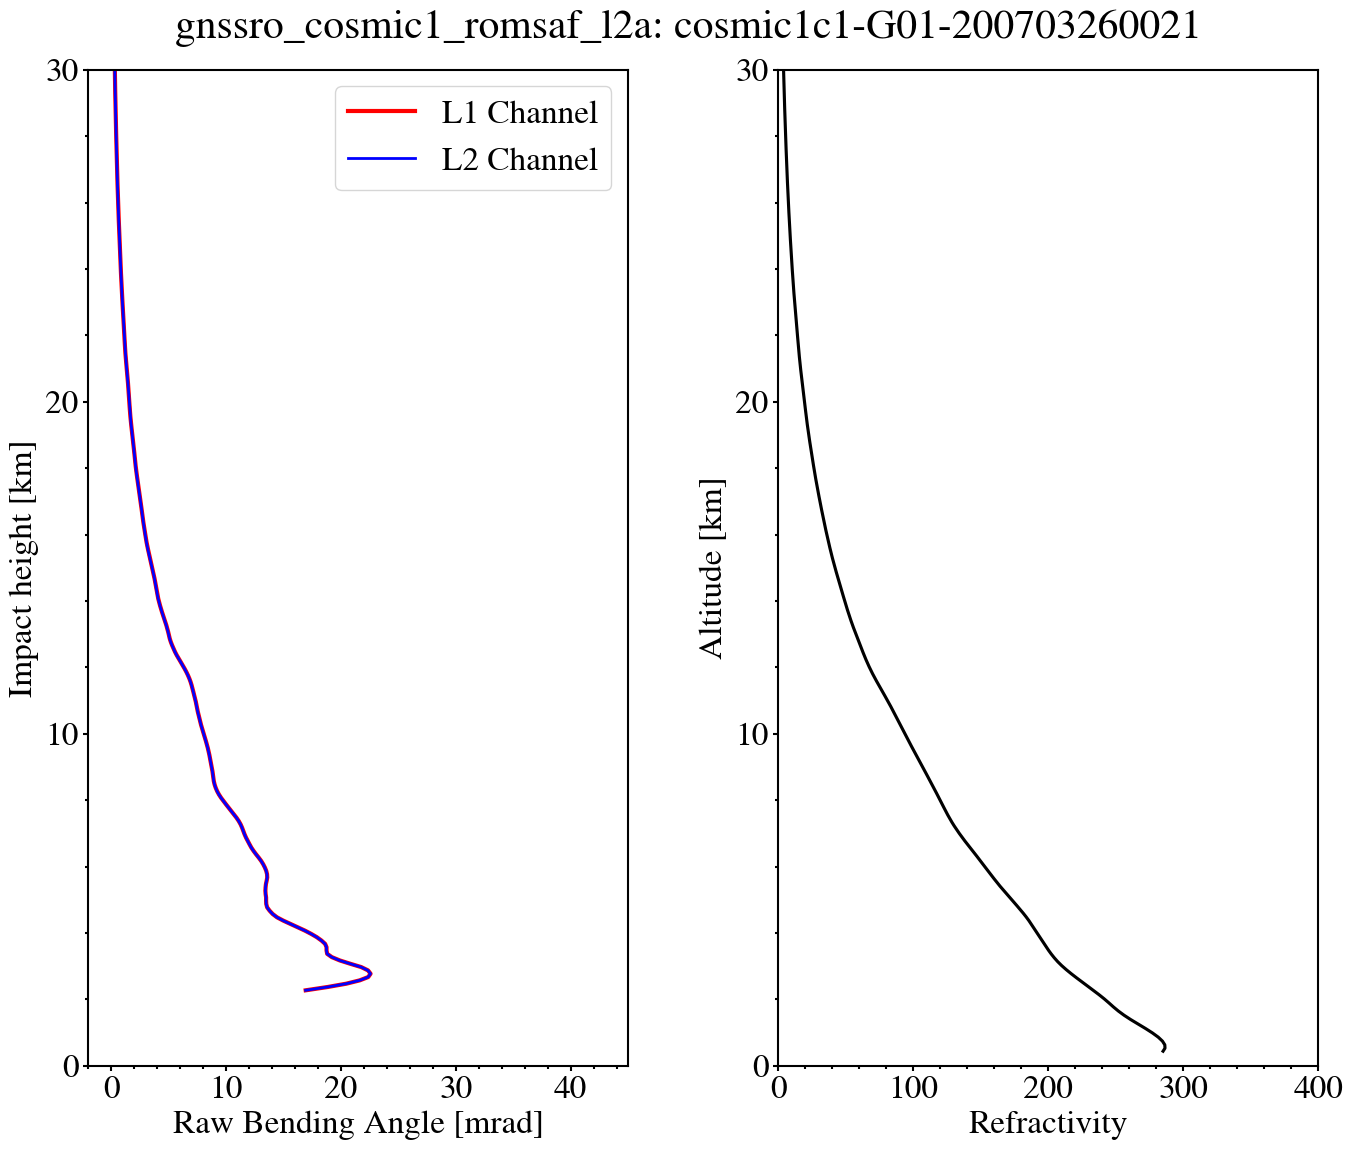

In [68]:
plot_l2a(l2a_local[0])

Now lets plot a Level 2B granule

In [69]:
def plot_l2b(l2b_file):

    #occid = l2b_file.split('.nc4')[0].split('_')[-1]
    occid = gen_occid(l2b_file)
    d = Dataset(l2b_file, 'r' )

    temperature = d.variables['temperature'][:]
    pressure = d.variables['pressure'][:]
    water_vapor_partial_pressure = d.variables['water_vapor_partial_pressure'][:]
    geopotential = d.variables['geopotential'][:]

    # get the relevant global attributes
    ShortName = d.ShortName
    d.close()

    #  Calculate specific humidity. 
    
    mudry, muwet = 29.652e-3, 18.02e-3
    specific_humidity = ( water_vapor_partial_pressure * muwet ) / ( (pressure-water_vapor_partial_pressure)*mudry + water_vapor_partial_pressure*muwet )
    height = geopotential / 9.80665e3
    
    fig = plt.figure( figsize=(15,10) )

    ax1 = fig.add_axes( [0.10,0.10,0.36,0.83] )
    ax2 = fig.add_axes( [0.56,0.10,0.36,0.83] )
    colors = ( "#FF0000", "#0000FF" )

    fig.suptitle(ShortName+': '+occid, fontsize=30)

    ax1.set_xlim( 180, 300 )
    ax1.set_xticks( np.arange(200,300.1,50) )
    ax1.xaxis.set_minor_locator( MultipleLocator(10) )
    ax1.set_ylim( 0.0, 30.0 )
    ax1.set_yticks( np.arange( 0.0, 30.01, 10 ) )
    ax1.yaxis.set_minor_locator( MultipleLocator(2) )
    ax1.set_xlabel( "Temperature [K]", fontsize = 24 )
    ax1.set_ylabel( "Geopotential height [km]", fontsize = 24 )
    ax1.plot( temperature, height, color=colors[0], lw=2.25 )
    
    #ax2.set_xlim( 0, 10 )
    ax2.set_xlim( 0, 15 )
    ax2.set_xticks( np.arange(0.0,10.1,5) )
    ax2.set_xticks( np.arange(0.0,15.1,5) )    
    ax2.xaxis.set_minor_locator( MultipleLocator(1) )
    ax2.set_ylim( 0.0, 30.0 )
    ax2.set_yticks( np.arange( 0.0, 30.01, 10.0 ) )
    ax2.yaxis.set_minor_locator( MultipleLocator(2) )
    ax2.set_xlabel( "Specific humidity [g/kg]", fontsize = 24 )
    ax2.set_ylabel( "Geopotential height [km]", fontsize = 24 )
    
    ax2.plot( specific_humidity*1000, height, color=colors[1], lw=2.25 )



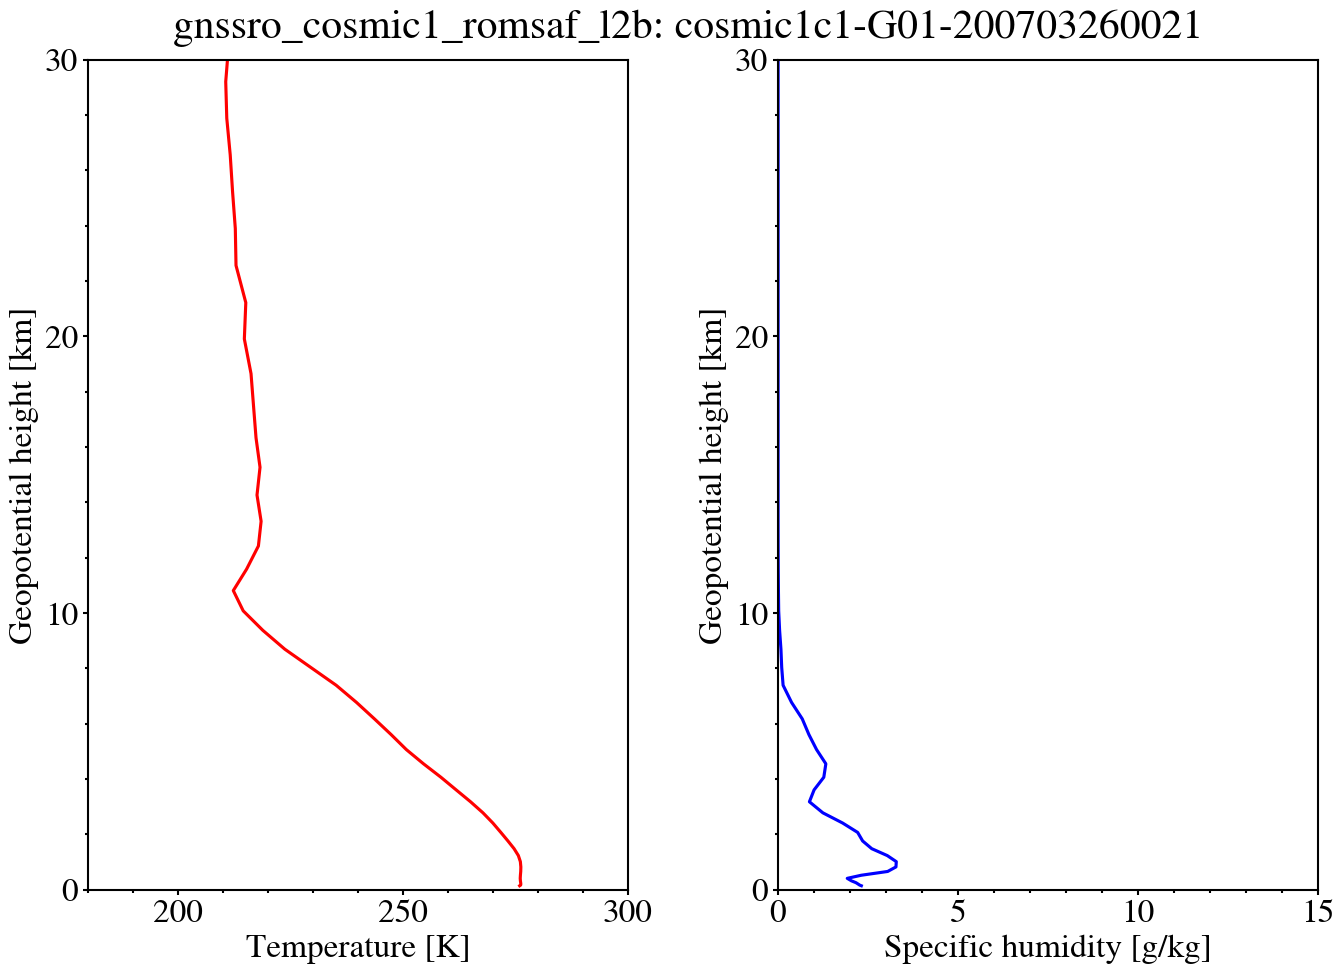

In [23]:
plot_l2b(l2b_local[0])

The above examples show how to plot the L1B from EUMETSAT, and the L2A and L2B data from ROMSAF.  Now lets search for the same occultation IDs processed at JPL and UCAR.  To find those data we can search those datasets for the same occultation ID.  The following function shows how to search for a given occultation ID withing a given product identified by the product ShortName.  Note that there is currently only one verson of this product but if additional versions are available in the future the result will have to be filtered by the version.

In [71]:
def get_OCCIDgranurls(ShortName,occid):
    '''
This program is similar to get_CMRgranurls since it returns the s3, opendap, and data urls for the all files with a given
shortname and occultation ID but it uses a url query rather than the python-cmr library.  

Notice that it does not specify the verison so if multiple versions exist for the same occultation ID, it will return all available
versions.
    '''
    url = 'https://cmr.earthdata.nasa.gov/search/granules.umm_json?short_name={}&attribute[]=string,ID,{}'.format(ShortName,occid)
    response = requests.get(url)
    s3_urls = []
    opendap_urls = []
    data_urls = []       
    if len(response.json()['items']) > 0:
        for item in response.json()['items'][0]['umm']['RelatedUrls']:
            if item['Type'] == 'GET DATA': # It is the netcdf url
                data_urls.append(item['URL'])    
            if item['Type'] == 'USE SERVICE API':
                if item['Subtype'] == 'OPENDAP DATA': # It's an opendap url
                    opendap_urls.append(item['URL'])
            if item['Type'] == 'GET DATA VIA DIRECT ACCESS': # It is an s3 url
                s3_urls.append(item['URL'])
                
        s3_urls = list(set(s3_urls)) # makes them unique and sorts them
        opendap_urls = list(set(opendap_urls)) # makes them unique and sorts them
        data_urls = list(set(data_urls)) # makes them unique and sorts them
        s3_urls.sort() # this will probably put them in chronological order but it must be verified.
        opendap_urls.sort() # this will probably put them in chronological order but it must be verified.
        data_urls.sort() # this will probably put them in chronological order but it must be verified.
        
    urls = {'s3':s3_urls,'opendap':opendap_urls,'data':data_urls}
    return urls

In [72]:
'''
We previously downloaded the Level 1b and Level 2 files with the occultation ID = 'cosmic1c1-G25-200703252358' that were
processed at EUMETSAT and ROMSAF. The following example uses get_OCCIDgranurls to search for the same occultation ID processed
by JPL and UCAR (as specified by the product shortnames).  
'''

occid = 'cosmic1c1-G25-200703252358'

cosmic1_jpl_l1b_occid_urls = get_OCCIDgranurls('gnssro_cosmic1_jpl_l1b',occid)
print(cosmic1_jpl_l1b_occid_urls['data'])

cosmic1_jpl_l2a_occid_urls = get_OCCIDgranurls('gnssro_cosmic1_jpl_l2a',occid)
print(cosmic1_jpl_l2a_occid_urls['data'])

cosmic1_jpl_l2b_occid_urls = get_OCCIDgranurls('gnssro_cosmic1_jpl_l2b',occid)
print(cosmic1_jpl_l2b_occid_urls['data'])

cosmic1_ucar_l1b_occid_urls = get_OCCIDgranurls('gnssro_cosmic1_ucar_l1b',occid)
print(cosmic1_ucar_l1b_occid_urls['data'])

cosmic1_ucar_l2a_occid_urls = get_OCCIDgranurls('gnssro_cosmic1_ucar_l2a',occid)
print(cosmic1_ucar_l2a_occid_urls['data'])

cosmic1_ucar_l2b_occid_urls = get_OCCIDgranurls('gnssro_cosmic1_ucar_l2b',occid)
print(cosmic1_ucar_l2b_occid_urls['data'])


['https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_jpl_l1b.2.0/2007/03/25/gnssro_cosmic1_jpl_l1b_v2.6_cosmic1c1-G25-200703252358.nc4']
['https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_jpl_l2a.2.0/2007/03/25/gnssro_cosmic1_jpl_l2a_v2.6_cosmic1c1-G25-200703252358.nc4']
['https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_jpl_l2b.2.0/2007/03/25/gnssro_cosmic1_jpl_l2b_v2.6_cosmic1c1-G25-200703252358.nc4']
[]
[]
[]


We see that this particular occultation ID was processed by JPL but not by UCAR.

In [73]:
# Let's download the JPL COSMIC1 data
cosmic1_jpl_l1b_local = download_granules(cosmic1_jpl_l1b_occid_urls['data'][0],datadir)
cosmic1_jpl_l2a_local = download_granules(cosmic1_jpl_l1b_occid_urls['data'][0],datadir)
cosmic1_jpl_l2b_local = download_granules(cosmic1_jpl_l1b_occid_urls['data'][0],datadir)

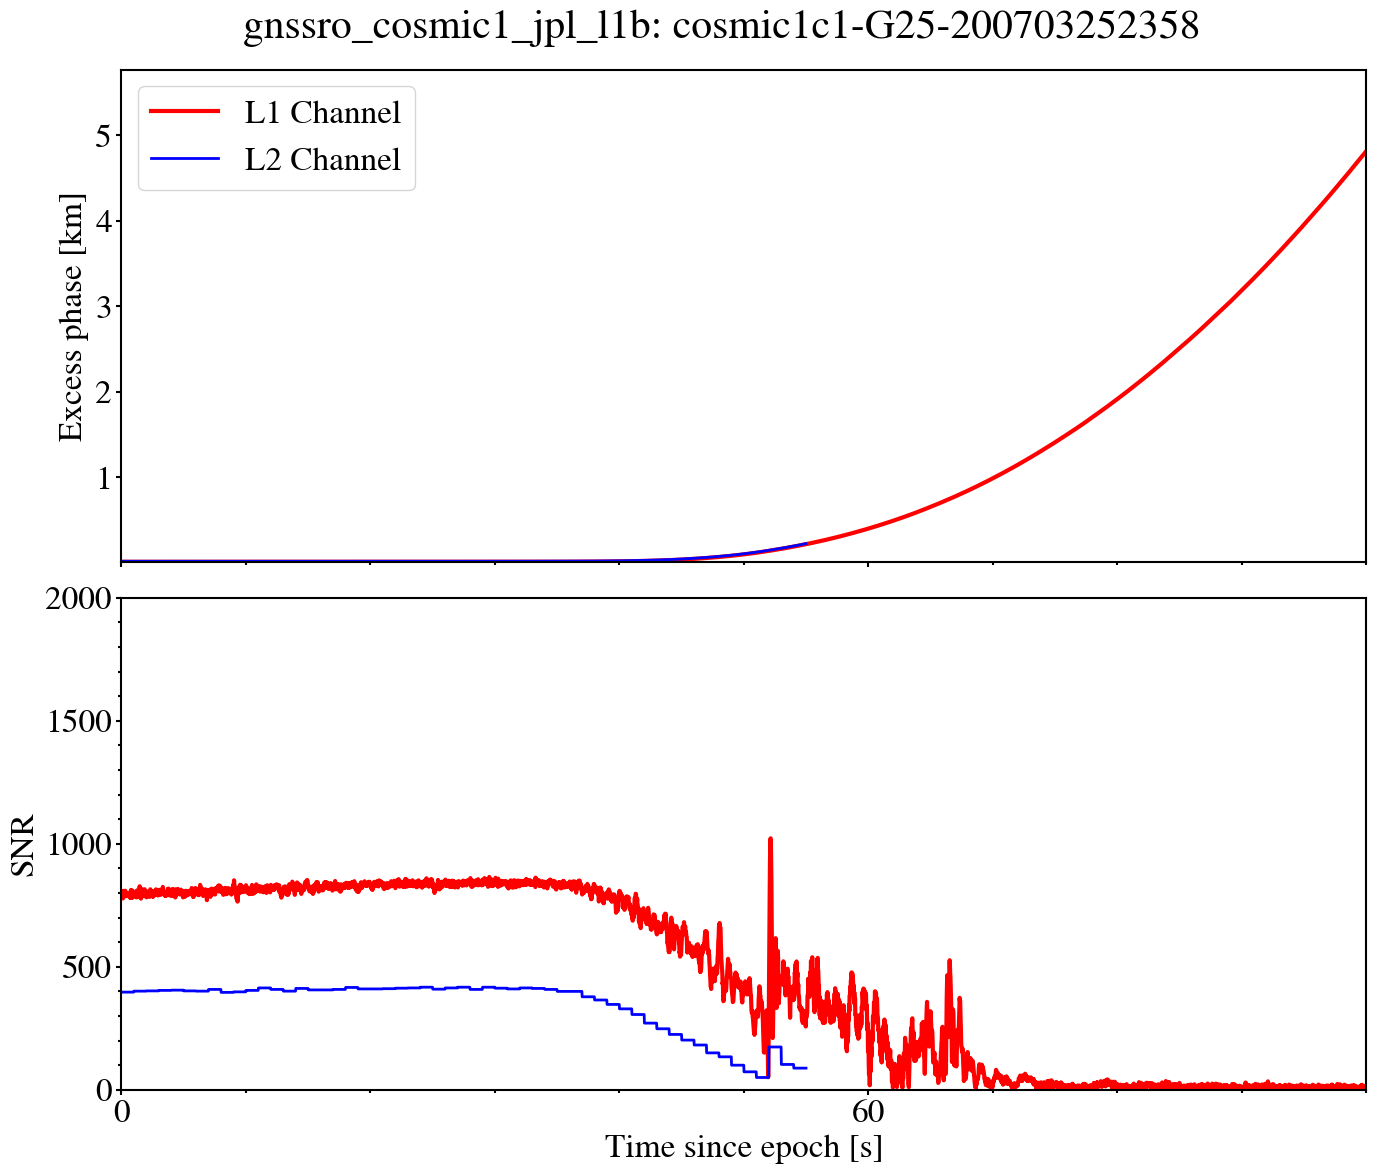

In [74]:
# Now let's plot it.
plot_l1b(cosmic1_jpl_l1b_local[0])

The excess phase and SNR appear to be different between the EUMETSAT and JPL data with the same occultation ID because they have subtracted a constant value to make the initial value close to zero.  Now, let's look at the L2A and L2B data.

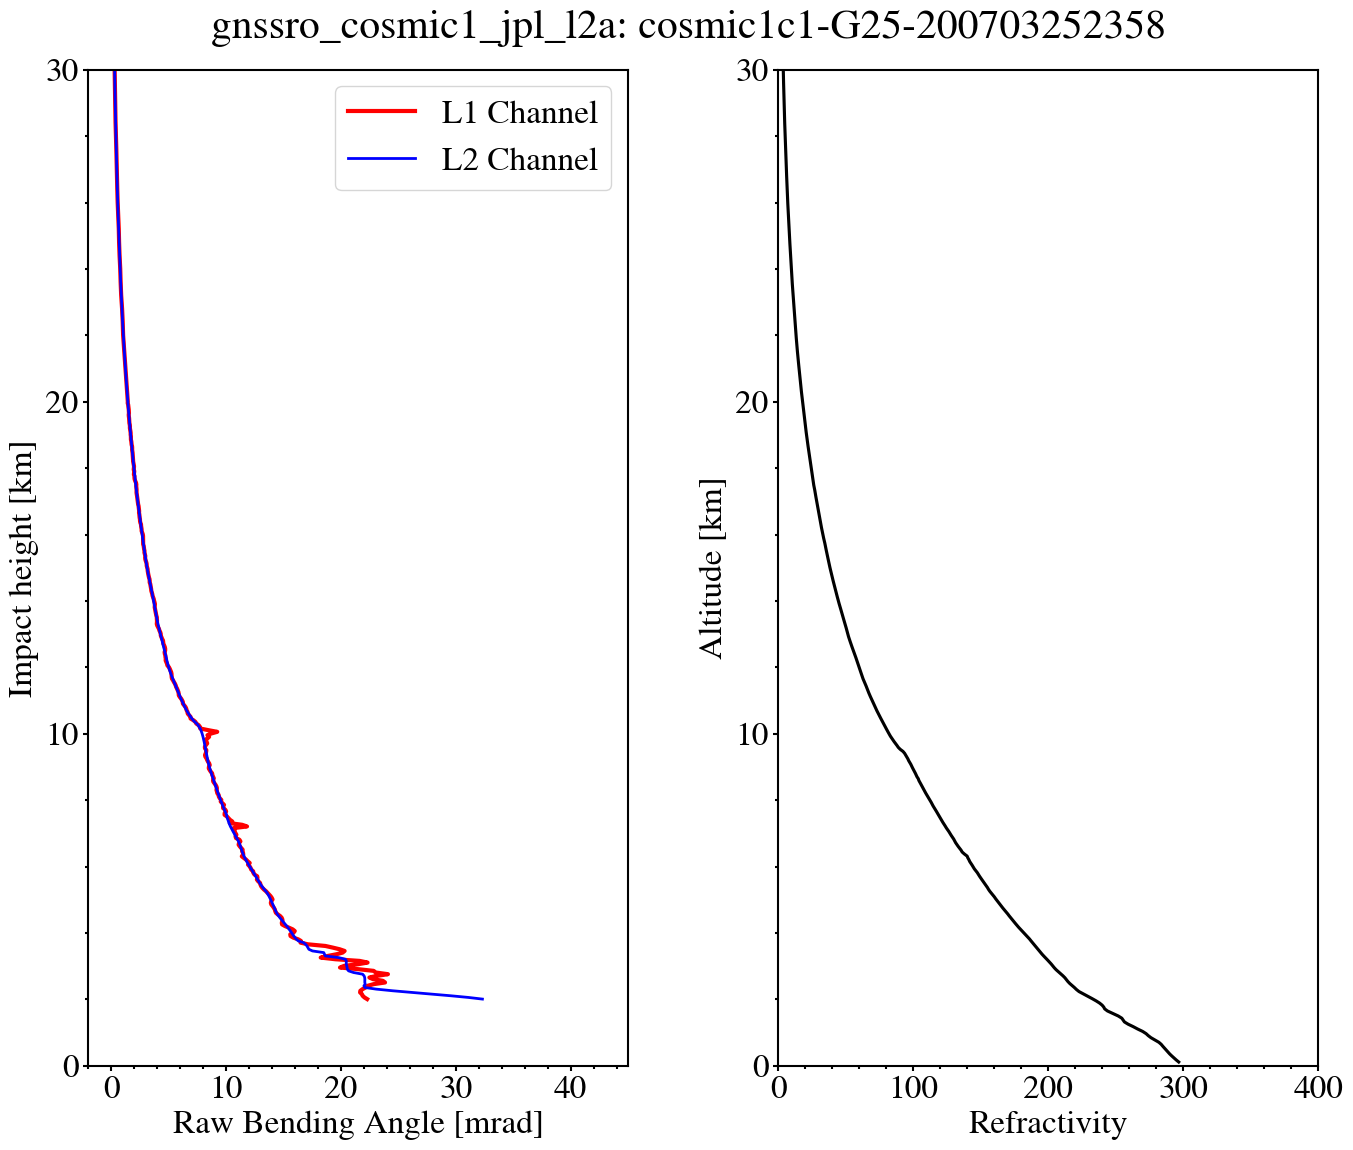

In [75]:
plot_l2a(cosmic1_jpl_l2a_local[0])

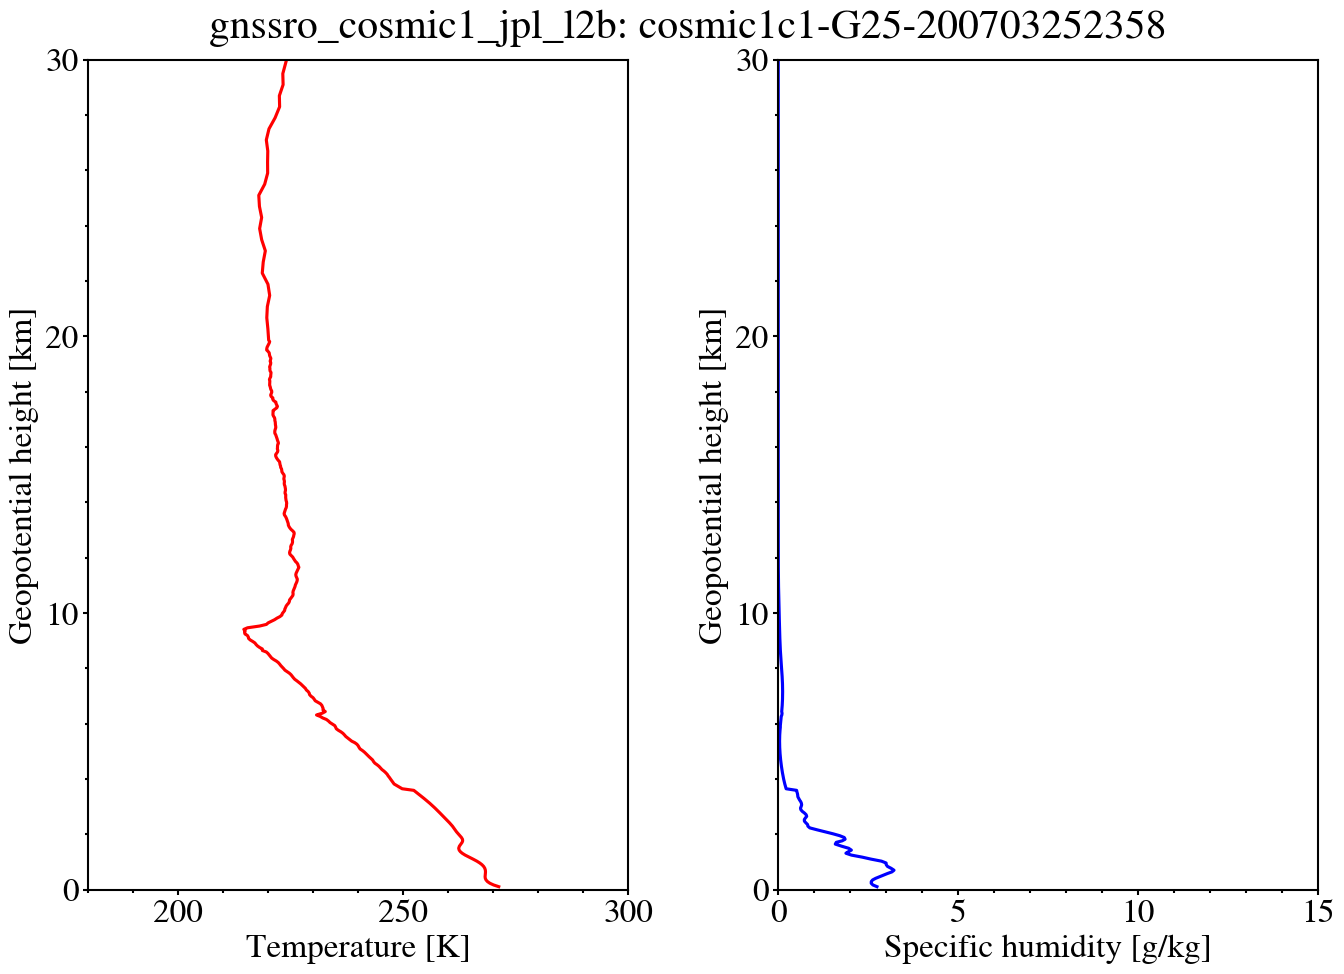

In [76]:
plot_l2b(cosmic1_jpl_l2b_local[0])

Now lets plot the data on a map.  The Level 1b files do not have geolocation information so they would need to be matched with the Level 2a or Level 2b data by their occultation IDs to obtain their golocation information.

The Level 2a files include both a reference_longitude and reference_latitude for the occultation as well as a longitude and latitude for each occultation tangent point included in the occultation.

The following example uses get_CMRgranurls to find all of the COSMIC1 occultations processed by UCAR that are within 200 km of New Orleans on 2007-03-26.

In [77]:
NO_ucar_l2a_urls,NO_out_time_start,NO_out_time_end =  get_CMRgranurls('gnssro_cosmic1_ucar_l2a','2.0','2007-03-26','2007-03-27',lon=-90.0715,lat=29.9511,rad_km=200.)

In [78]:
# The above search found 2 granules:
print(NO_ucar_l2a_urls['data'])

['https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2a.2.0/2007/03/26/gnssro_cosmic1_ucar_l2a_2021.0390_cosmic1c3-G13-200703260937.nc4', 'https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2a.2.0/2007/03/26/gnssro_cosmic1_ucar_l2a_2021.0390_cosmic1c4-G13-200703260931.nc4']


In [79]:
# lets download these 2 granules to the same data directory we crated before
NO_ucar_l2a_local = download_granules(NO_ucar_l2a_urls['data'],datadir)

Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2a.2.0/2007/03/26/gnssro_cosmic1_ucar_l2a_2021.0390_cosmic1c3-G13-200703260937.nc4
Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2a.2.0/2007/03/26/gnssro_cosmic1_ucar_l2a_2021.0390_cosmic1c4-G13-200703260931.nc4


Text(0.5, 1.0, 'COSMIC1 UCAR data within 200 km of New Orleans on 2007-03-26')

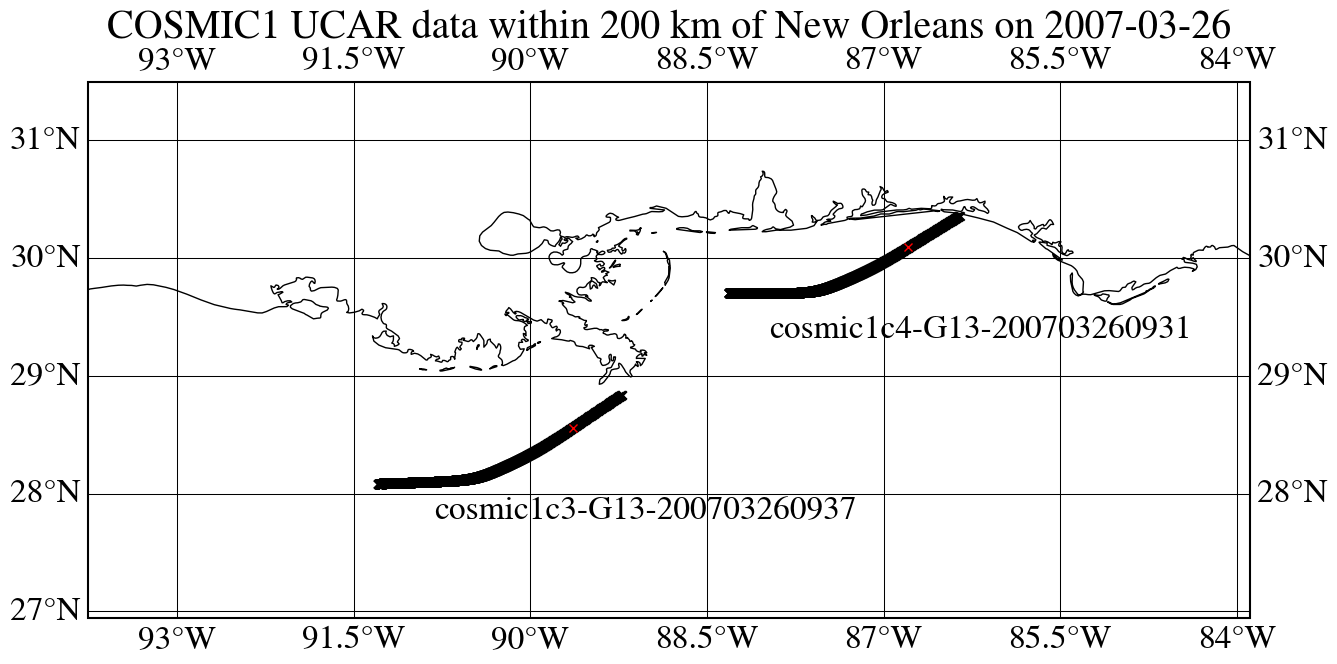

In [80]:
# Now we plot the 2 granules on a map to show the tangent points in black and the reference coordinats in red. 
mapprojection = ccrs.PlateCarree()

fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1, 1, 1, projection=mapprojection)  # Use PlateCarree or other projections
ax.coastlines()  # Add coastlines
gl=ax.gridlines(crs=mapprojection, draw_labels=True,linewidth=0.75, color='black')


for file in NO_ucar_l2a_local:
    occid = gen_occid(file)
    fid = Dataset(file ,mode='r',format='NETCDF4')
    
    reference_longitude = fid.variables['reference_longitude']
    reference_latitude = fid.variables['reference_latitude']   
    longitude = fid.groups['post_Abel'].variables['longitude']
    latitude = fid.groups['post_Abel'].variables['latitude']
    
    plt.scatter(longitude[:].data,latitude[:].data,transform=ccrs.Geodetic(), marker='x',color='k')
    plt.plot(reference_longitude[:].data,reference_latitude[:].data,marker='x',color='red',transform=ccrs.Geodetic())

    # shift the annotation to make the 
    ax.annotate(occid, xy=(reference_longitude[:].data,reference_latitude[:].data), xytext=(-100, -65),
            textcoords='offset points',
            transform=ccrs.PlateCarree())
    
    
    #ax1.legend(handles=[band0[0], band1[0]]) #*put back for all other GNSS RO
    
    #fid = Dataset(l2b_local[0] ,mode='r',format='NETCDF4')
    
    #reference_longitude = fid.variables['reference_longitude')
    #reference_latitude = fid.variables['reference_latitude']   
    
    #plt.plot(reference_longitude[:].data,reference_latitude[:].data,marker='+',color='green',transform=ccrs.Geodetic())
    
    fid.close()

ax.set_xmargin(0.5) # Add 50% padding to x-axis to see the occultation ID
ax.set_ymargin(0.5) # Add 50% padding to y-axis to see the occultation ID

ax.set_title("COSMIC1 UCAR data within 200 km of New Orleans on 2007-03-26")


In [ ]:
#The Level 2a files have both the tangent point coordinates as well as the reference point coordinates but the Level 2b files just
#contain the reference point coordinates.
#Even thought the Level 2b files are smaller than the Level 2a files it still takes a few minutes to download a full day of level 2b data.
#The following 2 lines show how to download all of the COSMIC1 Level 2b files from 2007-03-26 that were processed by UCAR.

ucar_l2b_urls,out_time_start,out_time_end =  get_CMRgranurls('gnssro_cosmic1_ucar_l2b','2.0','2007-03-26','2007-03-27')
ucar_l2b_local = download_granules(ucar_l2b_urls['data'],datadir)

Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2b.2.0/2007/03/26/gnssro_cosmic1_ucar_l2b_2021.0390_cosmic1c1-G01-200703260021.nc4Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2b.2.0/2007/03/26/gnssro_cosmic1_ucar_l2b_2021.0390_cosmic1c1-G01-200703260145.nc4

Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2b.2.0/2007/03/26/gnssro_cosmic1_ucar_l2b_2021.0390_cosmic1c1-G01-200703260229.nc4
Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2b.2.0/2007/03/26/gnssro_cosmic1_ucar_l2b_2021.0390_cosmic1c1-G01-200703260518.nc4
Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2b.2.0/2007/03/26/gnssro_cosmic1_ucar_l2b_2021.0390_cosmic1c1-G01-200703260645.nc4
Opening https://data.gesdisc.earthdata.nasa.gov/data/GNSSRO/gnssro_cosmic1_ucar_l2b.2.0/2007/03/26/gnssro_cosmic1_ucar_l2b_2021.0390_cosmic1c1-G01-200703260838.nc4
Opening https://

In [85]:
#The above search found 1938 granules.
len(ucar_l2b_local)

NameError: name 'ucar_l2b_local' is not defined

Text(0.5, 1.0, 'COSMIC1 UCAR data from 2007-03-26')

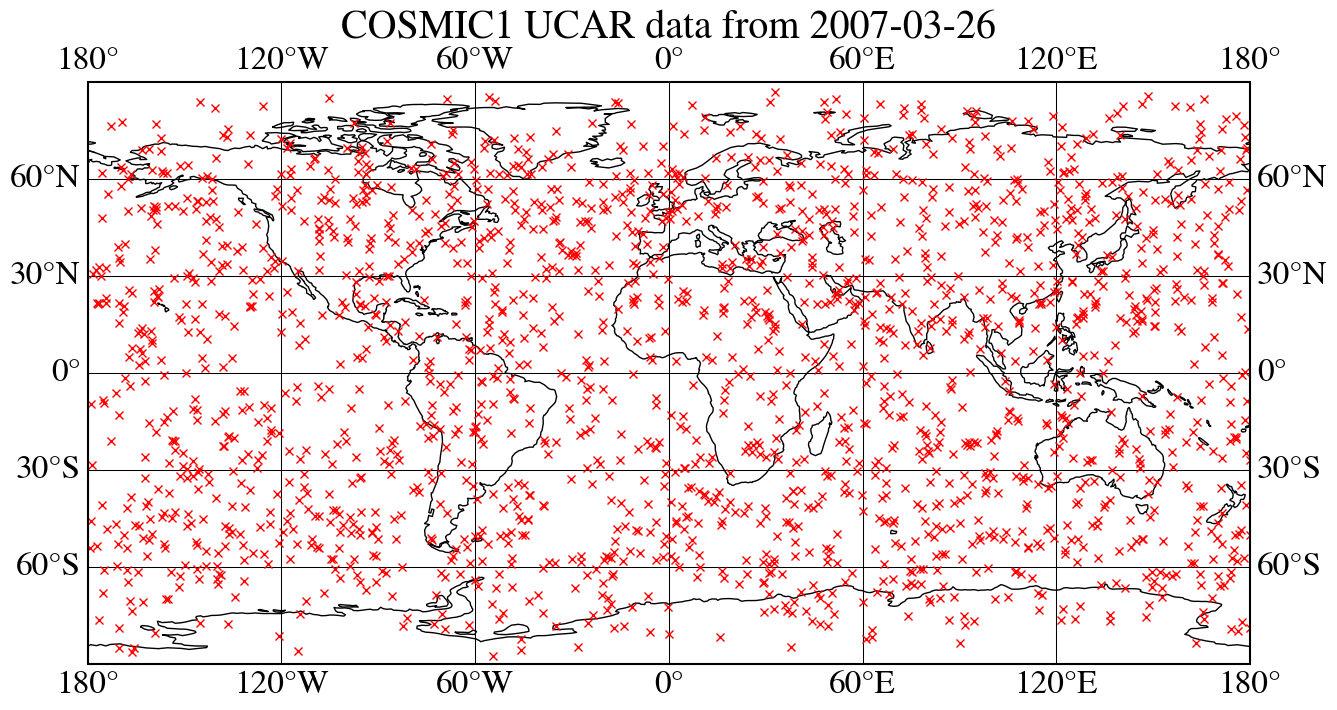

In [35]:
# Let's plot all of the reference coordinates on a map.
mapprojection = ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=mapprojection)  # Use PlateCarree or other projections
ax.coastlines()  # Add coastlines
gl=ax.gridlines(crs=mapprojection, draw_labels=True,linewidth=0.75, color='black')

for file in NO_ucar_l2b_local:

    fid = Dataset(file ,mode='r',format='NETCDF4')

    reference_longitude = fid.variables['reference_longitude']
    reference_latitude = fid.variables['reference_latitude']   
    
    plt.plot(reference_longitude[:].data,reference_latitude[:].data,marker='x',color='red',transform=ccrs.Geodetic())

    fid.close()     

ax.set_title('COSMIC1 UCAR data from 2007-03-26')
